In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf
from itertools import permutations
import warnings
warnings.filterwarnings('ignore')

# Output directory
OUTPUT_DIR = 'cannibalization_output/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'grid.linestyle':   '--',
    'font.size':        11,
})

BRAND_COLOR = {
    'Richeese': '#378ADD',
    'Richoco':  '#D4537E',
    'Nextar':   '#1D9E75',
}
CAT_COLOR = {
    'Wafer':          '#378ADD',
    'Kue/Pie':        '#1D9E75',
    'Minuman':        '#D4537E',
    'Mi Instan':      '#BA7517',
    'Extruded Snack': '#534AB7',
    'Biskuit':        '#888780',
}

print('✅ Config selesai')
print(f'   Output dir : {OUTPUT_DIR} — exists: {os.path.exists(OUTPUT_DIR)}')


✅ Config selesai
   Output dir : cannibalization_output/ — exists: True


In [3]:
DATA_PATH = 'cannibalization_output/simulated_dataset.csv'

sim_df = pd.read_csv(DATA_PATH)
sim_df['Date'] = pd.to_datetime(sim_df['Date'])

print(f'✅ Dataset loaded')
print(f'   Shape      : {sim_df.shape}')
print(f'   Date range : {sim_df["Date"].min().date()} → {sim_df["Date"].max().date()}')
print(f'   Unique SKU : {sim_df["SKU_ID"].nunique()}')
print(f'   Branches   : {sorted(sim_df["Branch"].unique())}')
print(f'\nKolom:')
print(sim_df.dtypes)
print(f'\nSample data:')
display(sim_df.head(5))


✅ Dataset loaded
   Shape      : (12240, 13)
   Date range : 2025-05-01 → 2025-09-30
   Unique SKU : 20
   Branches   : ['Bandung', 'Jakarta', 'Semarang', 'Surabaya']

Kolom:
Date                  datetime64[ns]
Month                          int64
Branch                        object
SKU_ID                        object
SKU_Name                      object
SKU_Category                  object
Brand                         object
NormalPrice                    int64
DiscountedPrice              float64
DiscountPercentage           float64
Promo_Category                object
Qty                            int64
Revenue                      float64
dtype: object

Sample data:


,Date,Month,Branch,SKU_ID,SKU_Name,SKU_Category,Brand,NormalPrice,DiscountedPrice,DiscountPercentage,Promo_Category,Qty,Revenue
0,2025-05-01,5,Bandung,S001,Richeese Wafer Keju 50g,Wafer,Richeese,5500,5225.0,0.050,Promo Bundling,310,1619750.0
1,2025-05-01,5,Bandung,S002,Richoco Wafer Cokelat 50g,Wafer,Richoco,6100,5642.5,0.075,Promo Normal,134,756095.0
2,2025-05-01,5,Bandung,S003,Richeese Wafer Keju 10g Renceng,Wafer,Richeese,10000,10000.0,0.000,No Promo,88,880000.0
3,2025-05-01,5,Bandung,S004,Richoco Wafer Cokelat 10g Renceng,Wafer,Richoco,10000,10000.0,0.000,No Promo,116,1160000.0
4,2025-05-01,5,Bandung,S005,Nextar Brownies Pie 40g,Kue/Pie,Nextar,8000,7400.0,0.075,Promo Normal,138,1021200.0


In [4]:
# Promo distribution
print('=== Promo Distribution ===')
print((sim_df['Promo_Category'].value_counts(normalize=True)*100).round(1))

# Avg discount per promo type
print('\n=== Avg Discount per Promo Type ===')
print(sim_df.groupby('Promo_Category')['DiscountPercentage'].mean().round(3))

# Price CV per SKU
print('\n=== Price CV per SKU ===')
cv = sim_df.groupby('SKU_ID')['DiscountedPrice'].agg(['mean','std'])
cv['cv_pct'] = (cv['std']/cv['mean']*100).round(2)
print(cv['cv_pct'].sort_values(ascending=False))


=== Promo Distribution ===
Promo_Category
No Promo               45.3
Promo Normal           29.6
Promo Bundling         15.7
Promo Seasonal High     9.4
Name: proportion, dtype: float64

=== Avg Discount per Promo Type ===
Promo_Category
No Promo               0.000
Promo Bundling         0.032
Promo Normal           0.075
Promo Seasonal High    0.250
Name: DiscountPercentage, dtype: float64

=== Price CV per SKU ===
SKU_ID
S013    21.67
S004     8.23
S008     8.15
S015     8.06
S016     8.01
S001     8.00
S019     7.92
S011     7.87
S006     7.86
S009     7.77
S003     7.72
S014     7.67
S012     7.66
S018     7.66
S017     7.62
S010     7.62
S020     7.57
S007     7.30
S002     7.14
S005     7.14
Name: cv_pct, dtype: float64


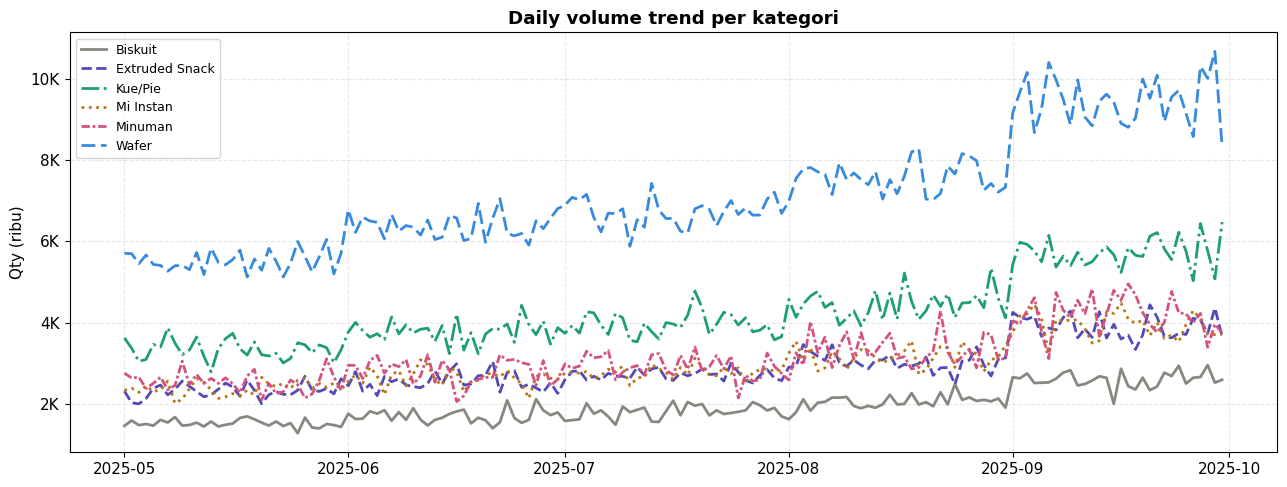

✅ Saved: 01_daily_trend.png


In [5]:
# Daily volume trend per kategori
daily_cat = sim_df.groupby(['Date','SKU_Category'])['Qty'].sum().reset_index()
pivot_cat = daily_cat.pivot(index='Date', columns='SKU_Category', values='Qty')

fig, ax = plt.subplots(figsize=(13, 5))
linestyles = ['-','--','-.',':',(0,(3,1,1,1)),(0,(5,2))]
for i, cat in enumerate(pivot_cat.columns):
    ax.plot(pivot_cat.index, pivot_cat[cat]/1000,
            label=cat, color=CAT_COLOR.get(cat,'#999'),
            linestyle=linestyles[i % len(linestyles)], linewidth=2)
ax.set_title('Daily volume trend per kategori', fontweight='bold')
ax.set_ylabel('Qty (ribu)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}K'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + '01_daily_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: 01_daily_trend.png')


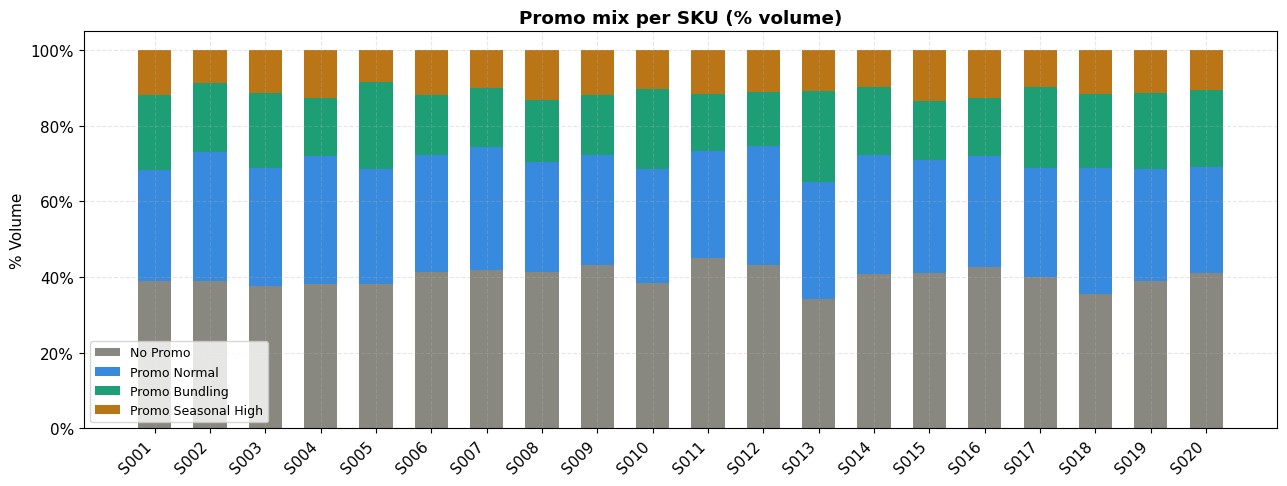

✅ Saved: 02_promo_mix.png


In [6]:
# Promo mix per SKU
promo_mix = sim_df.groupby(['SKU_ID','Promo_Category'])['Qty'].sum().reset_index()
promo_pivot = promo_mix.pivot(index='SKU_ID', columns='Promo_Category', values='Qty').fillna(0)
promo_pivot = promo_pivot.div(promo_pivot.sum(axis=1), axis=0) * 100

promo_colors = {
    'No Promo':            '#888780',
    'Promo Normal':        '#378ADD',
    'Promo Bundling':      '#1D9E75',
    'Promo Seasonal High': '#BA7517',
}

fig, ax = plt.subplots(figsize=(13, 5))
bottom = np.zeros(len(promo_pivot))
for pt in ['No Promo','Promo Normal','Promo Bundling','Promo Seasonal High']:
    if pt in promo_pivot.columns:
        vals = promo_pivot[pt].values
        ax.bar(promo_pivot.index, vals, bottom=bottom,
               label=pt, color=promo_colors[pt], width=0.6)
        bottom += vals
ax.set_title('Promo mix per SKU (% volume)', fontweight='bold')
ax.set_ylabel('% Volume')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
ax.legend(fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + '02_promo_mix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: 02_promo_mix.png')


In [7]:
sim_df['month_num'] = sim_df['Month'] - sim_df['Month'].min()
sim_df['log_qty']   = np.log(sim_df['Qty'] + 1)

# Pivot ke wide format
qty_wide  = sim_df.pivot_table(index=['Date','Branch'], columns='SKU_ID', values='log_qty')
disc_wide = sim_df.pivot_table(index=['Date','Branch'], columns='SKU_ID', values='DiscountPercentage')
meta_wide = sim_df.groupby(['Date','Branch'])[['month_num']].first()

sku_cat   = sim_df.groupby('SKU_ID')['SKU_Category'].first().to_dict()
sku_brand = sim_df.groupby('SKU_ID')['Brand'].first().to_dict()
sku_name  = sim_df.groupby('SKU_ID')['SKU_Name'].first().to_dict()

print(f'qty_wide shape  : {qty_wide.shape}')
print(f'disc_wide shape : {disc_wide.shape}')
print(f'\nN observasi per branch:')
print(sim_df.groupby('Branch').size() // sim_df['SKU_ID'].nunique())
print(f'\nSample qty_wide:')
display(qty_wide.head(3))


qty_wide shape  : (612, 20)
disc_wide shape : (612, 20)

N observasi per branch:
Branch
Bandung     153
Jakarta     153
Semarang    153
Surabaya    153
dtype: int64

Sample qty_wide:


SKU_ID                   S001      S002      S003      S004      S005  \
Date       Branch                                                       
2025-05-01 Bandung   5.739793  4.905275  4.488636  4.762174  4.934474   
           Jakarta   6.635947  6.021023  6.008813  5.905362  6.100319   
           Semarang  5.036953  4.189655  4.356709  4.488636  4.418841   

SKU_ID                   S006      S007      S008      S009      S010  \
Date       Branch                                                       
2025-05-01 Bandung   4.672829  4.828314  5.111988  4.477337  4.844187   
           Jakarta   6.001415  5.768321  5.673323  5.869297  5.823046   
           Semarang  4.521789  4.127134  4.304065  4.663439  3.663562   

SKU_ID                   S011      S012      S013      S014      S015  \
Date       Branch                                                       
2025-05-01 Bandung   4.442651  4.406719  5.620401  4.727388  4.787492   
           Jakarta   5.616771  6.171701  6.910751  6.107023  5.929589   
           Semarang  4.110874  4.204693  4.919981  4.564348  3.931826   

SKU_ID                   S016      S017      S018      S019      S020  
Date       Branch                                                      
2025-05-01 Bandung   4.644391  4.804021  5.056246  4.744932  4.962845  
           Jakarta   5.973810  6.126869  5.966147  5.690359  5.918894  
           Semarang  4.653960  4.276666  4.248495  4.290459  4.574711

In [8]:
results = []

for cat in sorted(sim_df['SKU_Category'].unique()):
    skus = [s for s, c in sku_cat.items() if c == cat]
    if len(skus) < 2:
        continue

    for sku_a, sku_b in permutations(skus, 2):
        try:
            reg_df = pd.DataFrame({
                'log_qty_B' : qty_wide[sku_b],
                'disc_pct_A': disc_wide[sku_a],
                'disc_pct_B': disc_wide[sku_b],
            }).join(meta_wide).reset_index().dropna()

            if len(reg_df) < 30:
                continue

            model = smf.ols(
                'log_qty_B ~ disc_pct_A + disc_pct_B + month_num + C(Branch)',
                data=reg_df
            ).fit()

            coef = model.params.get('disc_pct_A')
            pval = model.pvalues.get('disc_pct_A')
            if coef is None:
                continue

            results.append({
                'SKU_Category': cat,
                'SKU_A'       : sku_a,
                'SKU_A_Name'  : sku_name[sku_a],
                'Brand_A'     : sku_brand[sku_a],
                'SKU_B'       : sku_b,
                'SKU_B_Name'  : sku_name[sku_b],
                'Brand_B'     : sku_brand[sku_b],
                'coef_disc_A' : round(coef, 4),
                'p_value'     : round(pval, 4),
                'r_squared'   : round(model.rsquared, 4),
                'n_obs'       : len(reg_df),
            })
        except:
            continue

results_df = pd.DataFrame(results)

def verdict(row):
    if row['p_value'] >= 0.05:    return 'Tidak Signifikan'
    elif row['coef_disc_A'] < 0:  return 'CANNIBALIZATION'
    else:                          return 'KOMPLEMEN'

results_df['verdict'] = results_df.apply(verdict, axis=1)

print('=== VERDICT SUMMARY ===')
print(results_df['verdict'].value_counts())
print(f'\nTotal pasangan dianalisis: {len(results_df)}')


=== VERDICT SUMMARY ===
verdict
Tidak Signifikan    35
CANNIBALIZATION     19
KOMPLEMEN            4
Name: count, dtype: int64

Total pasangan dianalisis: 58


In [9]:
print('=== CANNIBALIZATION (p<0.05, coef negatif) ===')
c = results_df[results_df['verdict']=='CANNIBALIZATION'].sort_values('coef_disc_A')
display(c[['SKU_Category','SKU_A_Name','Brand_A','SKU_B_Name','Brand_B',
           'coef_disc_A','p_value','r_squared','n_obs']].reset_index(drop=True))

print(f'\n=== KOMPLEMEN (p<0.05, coef positif) ===')
k = results_df[results_df['verdict']=='KOMPLEMEN'].sort_values('coef_disc_A', ascending=False)
display(k[['SKU_Category','SKU_A_Name','Brand_A','SKU_B_Name','Brand_B',
           'coef_disc_A','p_value','r_squared','n_obs']].reset_index(drop=True))

results_df.to_csv(OUTPUT_DIR + 'cannibalization_results.csv', index=False)
print('\n✅ Saved: cannibalization_results.csv')


=== CANNIBALIZATION (p<0.05, coef negatif) ===


,SKU_Category,SKU_A_Name,Brand_A,SKU_B_Name,Brand_B,coef_disc_A,p_value,r_squared,n_obs
0,Mi Instan,Richeese Mi Instan Keju Pedas,Richeese,Richeese Mi Instan Ramen Keju,Richeese,-0.6396,0.0000,0.8682,612
1,Extruded Snack,Richeese Siip Keju 20g,Richeese,Richeese Siip Jagung Bakar 20g,Richeese,-0.6168,0.0000,0.8523,612
2,Wafer,Richeese Wafer Keju 50g,Richeese,Richoco Wafer Cokelat 50g,Richoco,-0.4841,0.0002,0.8702,612
3,Wafer,Richoco Wafer Cokelat 50g,Richoco,Richeese Wafer Keju 50g,Richeese,-0.4430,0.0032,0.8610,612
4,Minuman,Nabati Drinko Richoco 150ml,Richoco,Nabati Drinko Richeese 150ml,Richeese,-0.3928,0.0028,0.8800,612
5,Mi Instan,Richeese Mi Instan Goreng,Richeese,Richeese Mi Instan Keju Pedas,Richeese,-0.3792,0.0034,0.8771,612
6,Wafer,Richeese Wafer Pink Lava 50g,Richeese,Richeese Wafer Keju 50g,Richeese,-0.3766,0.0051,0.8608,612
7,Biskuit,Nabati Biskuit Rasa Kelapa,Richeese,Nabati Biskuit Rasa Cokelat,Richoco,-0.3625,0.0021,0.8876,612
8,Extruded Snack,Richeese Siip Keju 20g,Richeese,Richoco Ahh! Extruded 15g,Richoco,-0.3615,0.0093,0.8720,612
9,Mi Instan,Richeese Mi Instan Ramen Keju,Richeese,Richeese Mi Instan Keju Pedas,Richeese,-0.3495,0.0068,0.8768,612



=== KOMPLEMEN (p<0.05, coef positif) ===


,SKU_Category,SKU_A_Name,Brand_A,SKU_B_Name,Brand_B,coef_disc_A,p_value,r_squared,n_obs
0,Kue/Pie,Nextar Brownies Pie 40g,Nextar,Nextar Nastar Pie 30g,Nextar,0.3935,0.0017,0.8985,612
1,Wafer,Richeese Wafer Pink Lava 50g,Richeese,Richoco Wafer Cokelat 10g Renceng,Richoco,0.3202,0.0134,0.8621,612
2,Wafer,Richeese Wafer Keju 10g Renceng,Richeese,Richoco Wafer Cokelat 50g,Richoco,0.2957,0.0290,0.8683,612
3,Kue/Pie,Nextar Pineapple Pie 30g,Nextar,Nextar Nastar Pie 30g,Nextar,0.2479,0.0345,0.8976,612



✅ Saved: cannibalization_results.csv


In [14]:
# ── DIAGNOSTIC CHECKS ─────────────────────────────────────────

from scipy import stats as scipy_stats
import statsmodels.stats.diagnostic as smd

print("=" * 65)
print("DIAGNOSTIC CHECKS")
print("=" * 65)

diagnostic_rows = []

for cat in sorted(sim_df['SKU_Category'].unique()):
    skus = [s for s, c in sku_cat.items() if c == cat]
    if len(skus) < 2:
        continue

    for sku_a, sku_b in permutations(skus, 2):
        try:
            # ── Check 1: Minimum Price CV ──────────────────────
            cv_a = (disc_wide[sku_a].std() / disc_wide[sku_a].mean() * 100
                    if disc_wide[sku_a].mean() != 0 else 0)
            cv_b = (disc_wide[sku_b].std() / disc_wide[sku_b].mean() * 100
                    if disc_wide[sku_b].mean() != 0 else 0)
            cv_flag = 'PASS' if cv_a >= 10 else 'WARN: CV disc_A < 10%'

            # ── Check 2: Minimum N Observations ────────────────
            reg_df = pd.DataFrame({
                'log_qty_B' : qty_wide[sku_b],
                'disc_pct_A': disc_wide[sku_a],
                'disc_pct_B': disc_wide[sku_b],
            }).join(meta_wide).reset_index().dropna()
            n_obs    = len(reg_df)
            n_flag   = 'PASS' if n_obs >= 100 else f'WARN: n={n_obs} < 100'

            # ── Check 3: Residual Diagnostics ──────────────────
            model = smf.ols(
                'log_qty_B ~ disc_pct_A + disc_pct_B + month_num + C(Branch)',
                data=reg_df
            ).fit()
            residuals = model.resid

            # Normalitas residual — Shapiro-Wilk (pakai sample 200 kalau besar)
            sample    = residuals.sample(min(200, len(residuals)), random_state=42)
            _, p_norm = scipy_stats.shapiro(sample)
            norm_flag = 'PASS' if p_norm > 0.05 else f'WARN: residual non-normal (p={p_norm:.3f})'

            # Heteroskedastisitas — Breusch-Pagan test
            bp_test      = smd.het_breuschpagan(residuals, model.model.exog)
            p_hetero     = bp_test[1]
            hetero_flag  = 'PASS' if p_hetero > 0.05 else f'WARN: heteroskedastik (p={p_hetero:.3f})'

            # Overall reliability
            flags       = [cv_flag, n_flag, norm_flag, hetero_flag]
            any_warn    = any('WARN' in f for f in flags)
            reliability = 'UNRELIABLE' if any_warn else 'RELIABLE'

            diagnostic_rows.append({
                'SKU_Category' : cat,
                'SKU_A'        : sku_a,
                'SKU_B'        : sku_b,
                'cv_disc_A'    : round(cv_a, 2),
                'cv_flag'      : cv_flag,
                'n_obs'        : n_obs,
                'n_flag'       : n_flag,
                'norm_flag'    : norm_flag,
                'hetero_flag'  : hetero_flag,
                'reliability'  : reliability,
            })

        except:
            continue

diag_df = pd.DataFrame(diagnostic_rows)

# ── Summary ───────────────────────────────────────────────────
print(f"\nTotal pasangan dicek     : {len(diag_df)}")
print(f"RELIABLE                 : {(diag_df['reliability']=='RELIABLE').sum()}")
print(f"UNRELIABLE (ada warning) : {(diag_df['reliability']=='UNRELIABLE').sum()}")

print("\n=== Breakdown warning per check ===")
print(f"CV disc_A < 10%          : {diag_df['cv_flag'].str.contains('WARN').sum()} pasangan")
print(f"N obs < 100              : {diag_df['n_flag'].str.contains('WARN').sum()} pasangan")
print(f"Residual non-normal      : {diag_df['norm_flag'].str.contains('WARN').sum()} pasangan")
print(f"Heteroskedastik          : {diag_df['hetero_flag'].str.contains('WARN').sum()} pasangan")

print("\n=== Pasangan UNRELIABLE ===")
unreliable = diag_df[diag_df['reliability']=='UNRELIABLE']
if len(unreliable) == 0:
    print("Tidak ada — semua pasangan reliable ✅")
else:
    display(unreliable[['SKU_Category','SKU_A','SKU_B','cv_flag',
                         'n_flag','norm_flag','hetero_flag']].reset_index(drop=True))

diag_df.to_csv(OUTPUT_DIR + 'diagnostic_results.csv', index=False)
print("\n✅ Saved: diagnostic_results.csv")

DIAGNOSTIC CHECKS

Total pasangan dicek     : 58
RELIABLE                 : 18
UNRELIABLE (ada warning) : 40

=== Breakdown warning per check ===
CV disc_A < 10%          : 0 pasangan
N obs < 100              : 0 pasangan
Residual non-normal      : 40 pasangan
Heteroskedastik          : 5 pasangan

=== Pasangan UNRELIABLE ===


,SKU_Category,SKU_A,SKU_B,cv_flag,n_flag,norm_flag,hetero_flag
0,Extruded Snack,S007,S019,PASS,PASS,WARN: residual non-normal (p=0.001),PASS
1,Extruded Snack,S008,S019,PASS,PASS,WARN: residual non-normal (p=0.002),PASS
2,Kue/Pie,S005,S018,PASS,PASS,WARN: residual non-normal (p=0.000),WARN: heteroskedastik (p=0.010)
3,Kue/Pie,S006,S005,PASS,PASS,WARN: residual non-normal (p=0.000),PASS
4,Kue/Pie,S006,S018,PASS,PASS,WARN: residual non-normal (p=0.000),WARN: heteroskedastik (p=0.011)
5,Kue/Pie,S017,S005,PASS,PASS,WARN: residual non-normal (p=0.000),PASS
6,Kue/Pie,S017,S006,PASS,PASS,WARN: residual non-normal (p=0.014),PASS
7,Kue/Pie,S017,S018,PASS,PASS,WARN: residual non-normal (p=0.000),WARN: heteroskedastik (p=0.009)
8,Kue/Pie,S018,S005,PASS,PASS,WARN: residual non-normal (p=0.001),PASS
9,Kue/Pie,S018,S006,PASS,PASS,WARN: residual non-normal (p=0.018),PASS



✅ Saved: diagnostic_results.csv


In [17]:
print(f"diag_df shape: {diag_df.shape}")
print(f"diag_df columns: {diag_df.columns.tolist()}")
print(diag_df.head())

diag_df shape: (58, 10)
diag_df columns: ['SKU_Category', 'SKU_A', 'SKU_B', 'cv_disc_A', 'cv_flag', 'n_obs', 'n_flag', 'norm_flag', 'hetero_flag', 'reliability']
     SKU_Category SKU_A SKU_B  cv_disc_A cv_flag  n_obs n_flag  \
0         Biskuit  S011  S012     166.15    PASS    612   PASS   
1         Biskuit  S012  S011     155.68    PASS    612   PASS   
2  Extruded Snack  S007  S008     163.82    PASS    612   PASS   
3  Extruded Snack  S007  S019     163.82    PASS    612   PASS   
4  Extruded Snack  S008  S007     161.11    PASS    612   PASS   

                             norm_flag hetero_flag reliability  
0                                 PASS        PASS    RELIABLE  
1                                 PASS        PASS    RELIABLE  
2                                 PASS        PASS    RELIABLE  
3  WARN: residual non-normal (p=0.001)        PASS  UNRELIABLE  
4                                 PASS        PASS    RELIABLE  


In [18]:
# ── Filter hasil berdasarkan diagnostic ───────────────────────

# Reset results_df dari file yang sudah disave (hindari state issue)
results_df = pd.read_csv(OUTPUT_DIR + 'cannibalization_results.csv')

results_with_diag = results_df.merge(
    diag_df[['SKU_A','SKU_B','reliability']],
    on=['SKU_A','SKU_B'],
    how='left'
)

print(f"Kolom setelah merge: {results_with_diag.columns.tolist()}")
print(f"reliability value counts:\n{results_with_diag['reliability'].value_counts()}")

print("\n=== HASIL FINAL (hanya RELIABLE) ===")
reliable_results = results_with_diag[results_with_diag['reliability']=='RELIABLE']
print(f"Sebelum filter : {len(results_df)} pasangan")
print(f"Setelah filter : {len(reliable_results)} pasangan")
print()
print(reliable_results['verdict'].value_counts())

results_df = reliable_results.copy()

Kolom setelah merge: ['SKU_Category', 'SKU_A', 'SKU_A_Name', 'Brand_A', 'SKU_B', 'SKU_B_Name', 'Brand_B', 'coef_disc_A', 'p_value', 'r_squared', 'n_obs', 'verdict', 'reliability']
reliability value counts:
reliability
UNRELIABLE    40
RELIABLE      18
Name: count, dtype: int64

=== HASIL FINAL (hanya RELIABLE) ===
Sebelum filter : 58 pasangan
Setelah filter : 18 pasangan

verdict
Tidak Signifikan    9
CANNIBALIZATION     8
KOMPLEMEN           1
Name: count, dtype: int64


In [21]:
from scipy import stats as scipy_stats
import statsmodels.stats.diagnostic as smd
from statsmodels.stats.stattools import jarque_bera

print("=" * 65)
print("DIAGNOSTIC CHECKS")
print("=" * 65)

diagnostic_rows = []

for cat in sorted(sim_df['SKU_Category'].unique()):
    skus = [s for s, c in sku_cat.items() if c == cat]
    if len(skus) < 2:
        continue

    for sku_a, sku_b in permutations(skus, 2):
        try:
            # ── Check 1: Minimum Price CV ──────────────────────
            cv_a = (disc_wide[sku_a].std() / disc_wide[sku_a].mean() * 100
                    if disc_wide[sku_a].mean() != 0 else 0)
            cv_flag = 'PASS' if cv_a >= 10 else 'WARN: CV disc_A < 10%'

            # ── Check 2: Minimum N Observations ────────────────
            reg_df = pd.DataFrame({
                'log_qty_B' : qty_wide[sku_b],
                'disc_pct_A': disc_wide[sku_a],
                'disc_pct_B': disc_wide[sku_b],
            }).join(meta_wide).reset_index().dropna()
            n_obs  = len(reg_df)
            n_flag = 'PASS' if n_obs >= 100 else f'WARN: n={n_obs} < 100'

            # ── Check 3: Residual Diagnostics ──────────────────
            model     = smf.ols(
                'log_qty_B ~ disc_pct_A + disc_pct_B + month_num + C(Branch)',
                data=reg_df
            ).fit()
            residuals = model.resid

            # Normalitas — Jarque-Bera (lebih robust untuk n besar)
            _, p_norm, skew, _ = jarque_bera(residuals)
            norm_flag = 'PASS' if p_norm > 0.01 else f'WARN: non-normal JB (p={p_norm:.3f}, skew={skew:.2f})'

            # Heteroskedastisitas — Breusch-Pagan, threshold 0.01
            bp_test     = smd.het_breuschpagan(residuals, model.model.exog)
            p_hetero    = bp_test[1]
            hetero_flag = 'PASS' if p_hetero > 0.01 else f'WARN: heteroskedastik (p={p_hetero:.3f})'

            # Overall reliability
            flags       = [cv_flag, n_flag, norm_flag, hetero_flag]
            any_warn    = any('WARN' in f for f in flags)
            reliability = 'UNRELIABLE' if any_warn else 'RELIABLE'

            diagnostic_rows.append({
                'SKU_Category': cat,
                'SKU_A'       : sku_a,
                'SKU_B'       : sku_b,
                'cv_disc_A'   : round(cv_a, 2),
                'cv_flag'     : cv_flag,
                'n_obs'       : n_obs,
                'n_flag'      : n_flag,
                'norm_flag'   : norm_flag,
                'hetero_flag' : hetero_flag,
                'reliability' : reliability,
            })

        except:
            continue

diag_df = pd.DataFrame(diagnostic_rows)

print(f"\nTotal pasangan dicek     : {len(diag_df)}")
print(f"RELIABLE                 : {(diag_df['reliability']=='RELIABLE').sum()}")
print(f"UNRELIABLE (ada warning) : {(diag_df['reliability']=='UNRELIABLE').sum()}")

print("\n=== Breakdown warning per check ===")
print(f"CV disc_A < 10%          : {diag_df['cv_flag'].str.contains('WARN').sum()} pasangan")
print(f"N obs < 100              : {diag_df['n_flag'].str.contains('WARN').sum()} pasangan")
print(f"Residual non-normal      : {diag_df['norm_flag'].str.contains('WARN').sum()} pasangan")
print(f"Heteroskedastik          : {diag_df['hetero_flag'].str.contains('WARN').sum()} pasangan")

print("\n=== Pasangan UNRELIABLE ===")
unreliable = diag_df[diag_df['reliability']=='UNRELIABLE']
if len(unreliable) == 0:
    print("Tidak ada — semua pasangan reliable ✅")
else:
    display(unreliable[['SKU_Category','SKU_A','SKU_B','cv_flag',
                         'n_flag','norm_flag','hetero_flag']].reset_index(drop=True))

diag_df.to_csv(OUTPUT_DIR + 'diagnostic_results.csv', index=False)
print("\n✅ Saved: diagnostic_results.csv")

DIAGNOSTIC CHECKS

Total pasangan dicek     : 58
RELIABLE                 : 5
UNRELIABLE (ada warning) : 53

=== Breakdown warning per check ===
CV disc_A < 10%          : 0 pasangan
N obs < 100              : 0 pasangan
Residual non-normal      : 53 pasangan
Heteroskedastik          : 1 pasangan

=== Pasangan UNRELIABLE ===


,SKU_Category,SKU_A,SKU_B,cv_flag,n_flag,norm_flag,hetero_flag
0,Biskuit,S011,S012,PASS,PASS,"WARN: non-normal JB (p=0.005, skew=-0.26)",PASS
1,Biskuit,S012,S011,PASS,PASS,"WARN: non-normal JB (p=0.000, skew=-0.40)",PASS
2,Extruded Snack,S007,S008,PASS,PASS,"WARN: non-normal JB (p=0.000, skew=-0.24)",PASS
3,Extruded Snack,S007,S019,PASS,PASS,"WARN: non-normal JB (p=0.000, skew=-0.63)",PASS
4,Extruded Snack,S008,S019,PASS,PASS,"WARN: non-normal JB (p=0.000, skew=-0.60)",PASS
5,Extruded Snack,S019,S008,PASS,PASS,"WARN: non-normal JB (p=0.002, skew=-0.22)",PASS
6,Kue/Pie,S005,S017,PASS,PASS,"WARN: non-normal JB (p=0.000, skew=-0.33)",PASS
7,Kue/Pie,S005,S018,PASS,PASS,"WARN: non-normal JB (p=0.000, skew=-0.63)",PASS
8,Kue/Pie,S006,S005,PASS,PASS,"WARN: non-normal JB (p=0.000, skew=-0.43)",PASS
9,Kue/Pie,S006,S017,PASS,PASS,"WARN: non-normal JB (p=0.000, skew=-0.32)",PASS



✅ Saved: diagnostic_results.csv


In [23]:
from scipy import stats as scipy_stats
import statsmodels.stats.diagnostic as smd
from statsmodels.stats.stattools import jarque_bera

print("=" * 65)
print("DIAGNOSTIC CHECKS")
print("=" * 65)

diagnostic_rows = []

for cat in sorted(sim_df['SKU_Category'].unique()):
    skus = [s for s, c in sku_cat.items() if c == cat]
    if len(skus) < 2:
        continue

    for sku_a, sku_b in permutations(skus, 2):
        try:
            # ── Check 1: Minimum Price CV ──────────────────────
            cv_a    = (disc_wide[sku_a].std() / disc_wide[sku_a].mean() * 100
                       if disc_wide[sku_a].mean() != 0 else 0)
            cv_flag = 'PASS' if cv_a >= 10 else 'WARN: CV disc_A < 10%'

            # ── Check 2: Minimum N Observations ────────────────
            reg_df = pd.DataFrame({
                'log_qty_B' : qty_wide[sku_b],
                'disc_pct_A': disc_wide[sku_a],
                'disc_pct_B': disc_wide[sku_b],
            }).join(meta_wide).reset_index().dropna()
            n_obs  = len(reg_df)
            n_flag = 'PASS' if n_obs >= 100 else f'WARN: n={n_obs} < 100'

            # ── Check 3: Residual Diagnostics ──────────────────
            model     = smf.ols(
                'log_qty_B ~ disc_pct_A + disc_pct_B + month_num + C(Branch)',
                data=reg_df
            ).fit()
            residuals = model.resid

            # Normalitas — skewness threshold |skew| < 1.0
            _, _, skew, _ = jarque_bera(residuals)
            norm_flag     = 'PASS' if abs(skew) < 1.0 else f'WARN: high skew ({skew:.2f})'

            # Heteroskedastisitas — Breusch-Pagan, threshold 0.01
            bp_test     = smd.het_breuschpagan(residuals, model.model.exog)
            p_hetero    = bp_test[1]
            hetero_flag = 'PASS' if p_hetero > 0.01 else f'WARN: heteroskedastik (p={p_hetero:.3f})'

            # Overall reliability
            flags       = [cv_flag, n_flag, norm_flag, hetero_flag]
            any_warn    = any('WARN' in f for f in flags)
            reliability = 'UNRELIABLE' if any_warn else 'RELIABLE'

            diagnostic_rows.append({
                'SKU_Category': cat,
                'SKU_A'       : sku_a,
                'SKU_B'       : sku_b,
                'cv_disc_A'   : round(cv_a, 2),
                'cv_flag'     : cv_flag,
                'n_obs'       : n_obs,
                'n_flag'      : n_flag,
                'skew'        : round(skew, 3),
                'norm_flag'   : norm_flag,
                'hetero_flag' : hetero_flag,
                'reliability' : reliability,
            })

        except:
            continue

diag_df = pd.DataFrame(diagnostic_rows)

print(f"\nTotal pasangan dicek     : {len(diag_df)}")
print(f"RELIABLE                 : {(diag_df['reliability']=='RELIABLE').sum()}")
print(f"UNRELIABLE (ada warning) : {(diag_df['reliability']=='UNRELIABLE').sum()}")

print("\n=== Breakdown warning per check ===")
print(f"CV disc_A < 10%          : {diag_df['cv_flag'].str.contains('WARN').sum()} pasangan")
print(f"N obs < 100              : {diag_df['n_flag'].str.contains('WARN').sum()} pasangan")
print(f"|Skew| >= 1.0            : {diag_df['norm_flag'].str.contains('WARN').sum()} pasangan")
print(f"Heteroskedastik          : {diag_df['hetero_flag'].str.contains('WARN').sum()} pasangan")

print("\n=== Pasangan UNRELIABLE ===")
unreliable = diag_df[diag_df['reliability']=='UNRELIABLE']
if len(unreliable) == 0:
    print("Tidak ada — semua pasangan reliable ✅")
else:
    display(unreliable[['SKU_Category','SKU_A','SKU_B','cv_flag',
                         'n_flag','norm_flag','hetero_flag']].reset_index(drop=True))

diag_df.to_csv(OUTPUT_DIR + 'diagnostic_results.csv', index=False)
print("\n✅ Saved: diagnostic_results.csv")

DIAGNOSTIC CHECKS

Total pasangan dicek     : 58
RELIABLE                 : 47
UNRELIABLE (ada warning) : 11

=== Breakdown warning per check ===
CV disc_A < 10%          : 0 pasangan
N obs < 100              : 0 pasangan
|Skew| >= 1.0            : 10 pasangan
Heteroskedastik          : 1 pasangan

=== Pasangan UNRELIABLE ===


,SKU_Category,SKU_A,SKU_B,cv_flag,n_flag,norm_flag,hetero_flag
0,Kue/Pie,S017,S018,PASS,PASS,PASS,WARN: heteroskedastik (p=0.009)
1,Wafer,S001,S015,PASS,PASS,WARN: high skew (-1.29),PASS
2,Wafer,S001,S016,PASS,PASS,WARN: high skew (-1.67),PASS
3,Wafer,S002,S015,PASS,PASS,WARN: high skew (-1.25),PASS
4,Wafer,S002,S016,PASS,PASS,WARN: high skew (-1.67),PASS
5,Wafer,S003,S015,PASS,PASS,WARN: high skew (-1.25),PASS
6,Wafer,S003,S016,PASS,PASS,WARN: high skew (-1.58),PASS
7,Wafer,S004,S015,PASS,PASS,WARN: high skew (-1.25),PASS
8,Wafer,S004,S016,PASS,PASS,WARN: high skew (-1.69),PASS
9,Wafer,S015,S016,PASS,PASS,WARN: high skew (-1.66),PASS



✅ Saved: diagnostic_results.csv


In [24]:
# Reset results_df dari file
results_df = pd.read_csv(OUTPUT_DIR + 'cannibalization_results.csv')

results_with_diag = results_df.merge(
    diag_df[['SKU_A','SKU_B','reliability']],
    on=['SKU_A','SKU_B'],
    how='left'
)

print("=== HASIL FINAL (hanya RELIABLE) ===")
reliable_results = results_with_diag[results_with_diag['reliability']=='RELIABLE']
print(f"Sebelum filter : {len(results_df)} pasangan")
print(f"Setelah filter : {len(reliable_results)} pasangan")
print()
print(reliable_results['verdict'].value_counts())

results_df = reliable_results.copy()

=== HASIL FINAL (hanya RELIABLE) ===
Sebelum filter : 58 pasangan
Setelah filter : 47 pasangan

verdict
Tidak Signifikan    26
CANNIBALIZATION     17
KOMPLEMEN            4
Name: count, dtype: int64


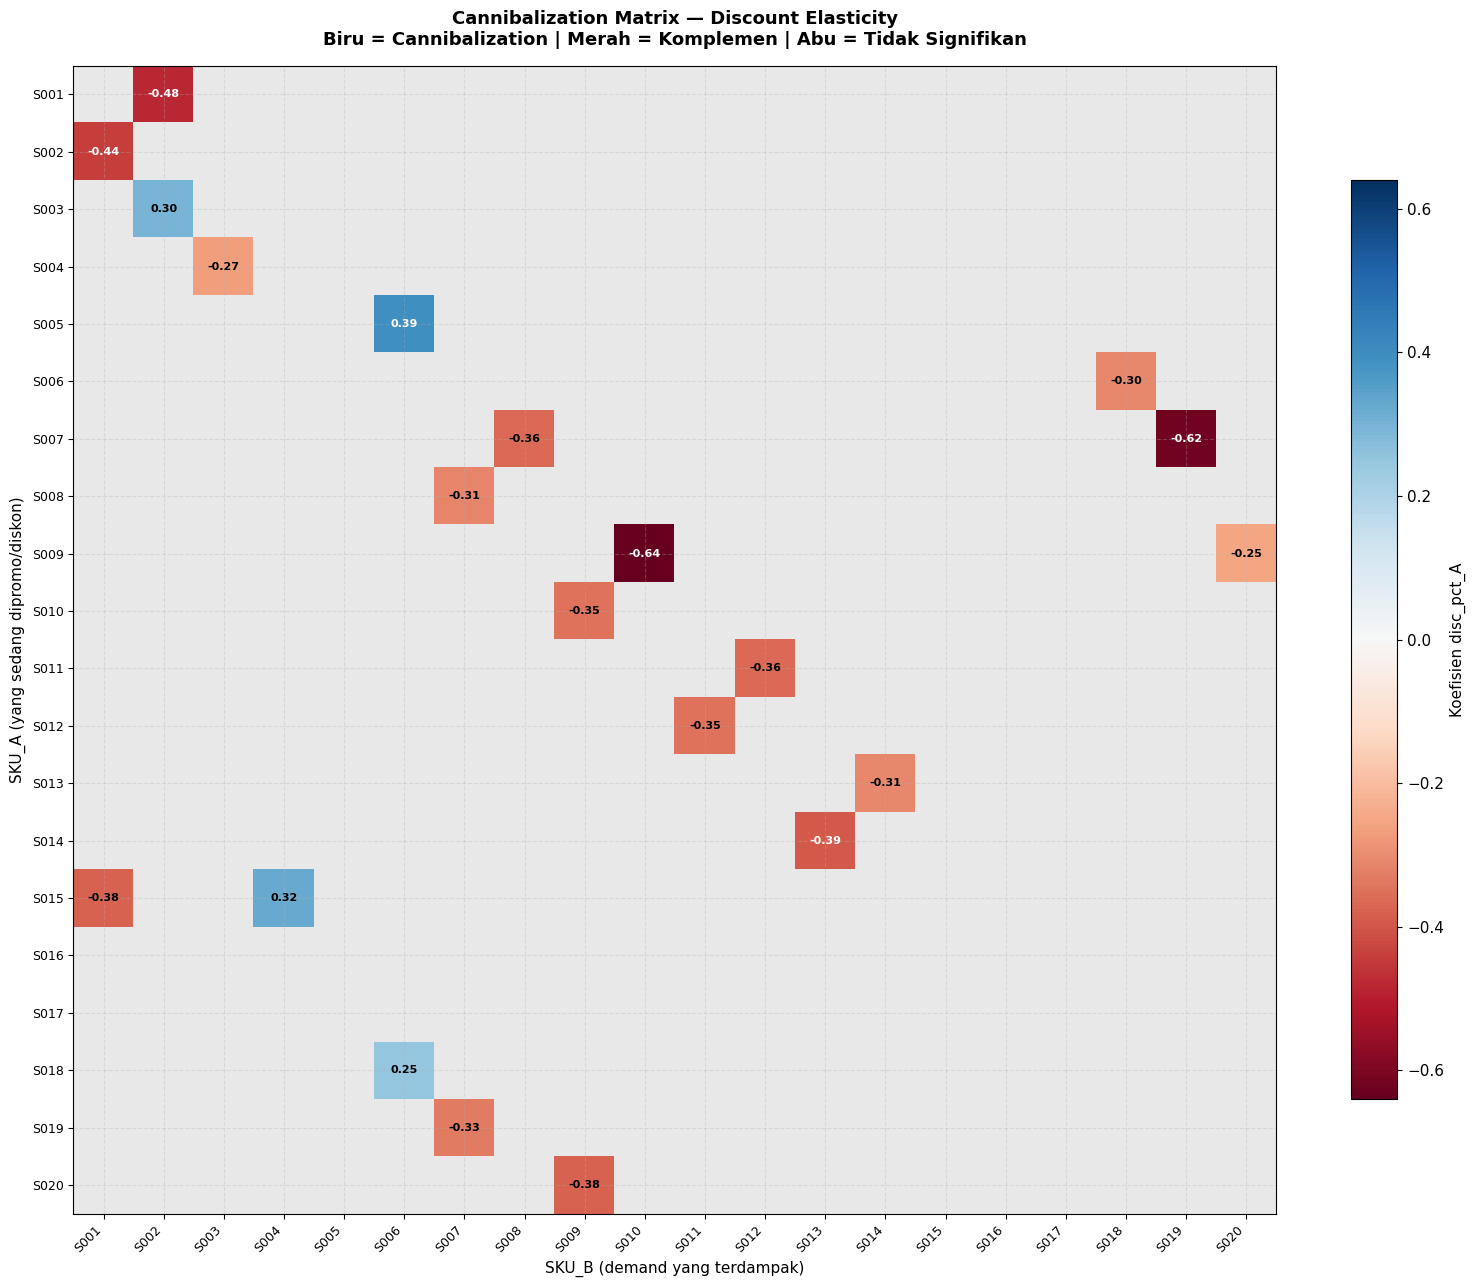

✅ Saved: 03_cannibalization_matrix.png


In [25]:
all_skus = sorted(set(results_df['SKU_A'].unique()) | set(results_df['SKU_B'].unique()))
matrix   = pd.DataFrame(np.nan, index=all_skus, columns=all_skus)

for _, row in results_df.iterrows():
    if row['verdict'] != 'Tidak Signifikan':
        matrix.loc[row['SKU_A'], row['SKU_B']] = row['coef_disc_A']

fig, ax = plt.subplots(figsize=(16, 13))
cmap = plt.cm.RdBu
cmap.set_bad(color='#E8E8E8')

vals        = matrix.values.astype(float)
finite_vals = vals[np.isfinite(vals)]
vmax        = max(abs(finite_vals).max(), 0.5) if len(finite_vals) > 0 else 1.0

im = ax.imshow(vals, cmap=cmap, vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(len(all_skus)))
ax.set_yticks(range(len(all_skus)))
ax.set_xticklabels(all_skus, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(all_skus, fontsize=9)

for i, sku_a in enumerate(all_skus):
    for j, sku_b in enumerate(all_skus):
        val = matrix.loc[sku_a, sku_b]
        if not np.isnan(val):
            color = 'white' if abs(val) > vmax * 0.6 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=8, color=color, fontweight='bold')

ax.set_xlabel('SKU_B (demand yang terdampak)', fontsize=11)
ax.set_ylabel('SKU_A (yang sedang dipromo/diskon)', fontsize=11)
ax.set_title(
    'Cannibalization Matrix — Discount Elasticity\n'
    'Biru = Cannibalization | Merah = Komplemen | Abu = Tidak Signifikan',
    fontsize=13, fontweight='bold', pad=15
)
plt.colorbar(im, ax=ax, label='Koefisien disc_pct_A', shrink=0.8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + '03_cannibalization_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: 03_cannibalization_matrix.png')


In [26]:
daily_rev = sim_df.groupby('SKU_ID')['Revenue'].mean().reset_index()
daily_rev.columns = ['SKU_ID', 'avg_daily_rev']

cannibal_df = results_df[results_df['verdict'] == 'CANNIBALIZATION'].copy()
impact_rows = []

for _, row in cannibal_df.iterrows():
    rev_b      = daily_rev[daily_rev['SKU_ID'] == row['SKU_B']]['avg_daily_rev'].values[0]
    pct_change = row['coef_disc_A'] * 0.10
    impact_rows.append({
        'SKU_Category'    : row['SKU_Category'],
        'SKU_A'           : row['SKU_A'],
        'SKU_A_Name'      : row['SKU_A_Name'],
        'SKU_B'           : row['SKU_B'],
        'SKU_B_Name'      : row['SKU_B_Name'],
        'coef_disc_A'     : row['coef_disc_A'],
        'p_value'         : row['p_value'],
        'avg_daily_rev_B' : round(rev_b, 0),
        'pct_qty_change'  : round(pct_change * 100, 2),
        'daily_rev_impact': round(rev_b * pct_change, 0),
    })

impact_df = pd.DataFrame(impact_rows).sort_values('daily_rev_impact')

print('=== REVENUE IMPACT per 10pp kenaikan diskon SKU_A ===')
display(impact_df[['SKU_Category','SKU_A_Name','SKU_B_Name',
                   'pct_qty_change','avg_daily_rev_B','daily_rev_impact']].reset_index(drop=True))

impact_df.to_csv(OUTPUT_DIR + 'revenue_impact.csv', index=False)
print('\n✅ Saved: revenue_impact.csv')


=== REVENUE IMPACT per 10pp kenaikan diskon SKU_A ===


,SKU_Category,SKU_A_Name,SKU_B_Name,pct_qty_change,avg_daily_rev_B,daily_rev_impact
0,Wafer,Richoco Wafer Cokelat 50g,Richeese Wafer Keju 50g,-4.43,2688824.0,-119115.0
1,Wafer,Richeese Wafer Pink Lava 50g,Richeese Wafer Keju 50g,-3.77,2688824.0,-101261.0
2,Minuman,Nabati Drinko Richoco 150ml,Nabati Drinko Richeese 150ml,-3.93,1818103.0,-71415.0
3,Wafer,Richeese Wafer Keju 50g,Richoco Wafer Cokelat 50g,-4.84,1426901.0,-69076.0
4,Wafer,Richoco Wafer Cokelat 10g Renceng,Richeese Wafer Keju 10g Renceng,-2.67,2358379.0,-62992.0
5,Mi Instan,Richeese Mi Instan Keju Pedas,Richeese Mi Instan Ramen Keju,-6.40,942165.0,-60261.0
6,Kue/Pie,Nextar Nastar Pie 30g,Nextar Pineapple Pie 30g,-3.05,1736408.0,-52960.0
7,Extruded Snack,Richeese Siip Keju 20g,Richeese Siip Jagung Bakar 20g,-6.17,704505.0,-43454.0
8,Biskuit,Nabati Biskuit Rasa Kelapa,Nabati Biskuit Rasa Cokelat,-3.62,1139814.0,-41318.0
9,Biskuit,Nabati Biskuit Rasa Cokelat,Nabati Biskuit Rasa Kelapa,-3.48,1159237.0,-40295.0



✅ Saved: revenue_impact.csv


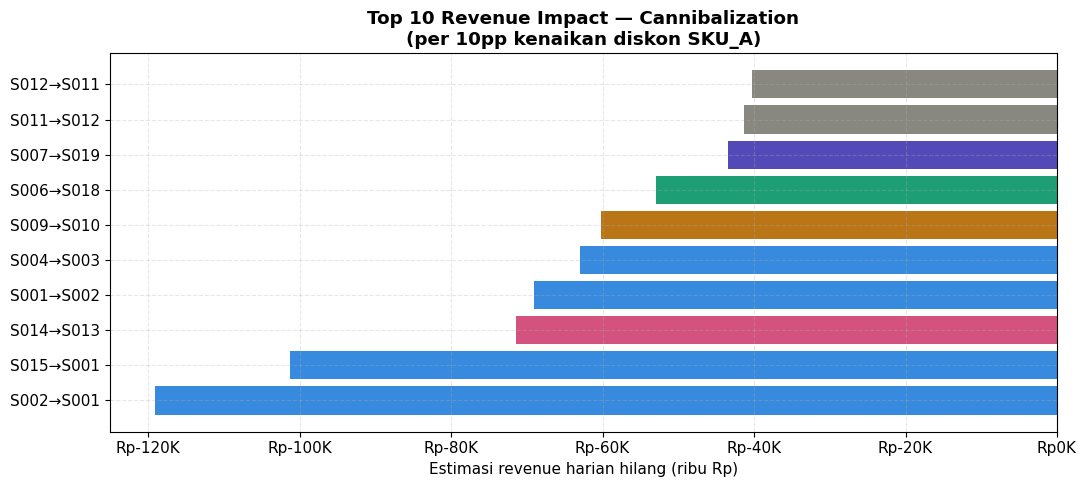

✅ Saved: 04_revenue_impact.png


In [27]:
# Bar chart top 10 revenue impact
top10  = impact_df.nsmallest(10, 'daily_rev_impact')
colors = [CAT_COLOR.get(c, '#999') for c in top10['SKU_Category']]
labels = [f"{r['SKU_A']}→{r['SKU_B']}" for _, r in top10.iterrows()]

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(labels, top10['daily_rev_impact'] / 1000, color=colors)
ax.set_xlabel('Estimasi revenue harian hilang (ribu Rp)')
ax.set_title('Top 10 Revenue Impact — Cannibalization\n(per 10pp kenaikan diskon SKU_A)',
             fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rp{x:.0f}K'))
plt.tight_layout()
plt.savefig(OUTPUT_DIR + '04_revenue_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: 04_revenue_impact.png')


In [28]:
print('=' * 65)
print('RINGKASAN HASIL CANNIBALIZATION ANALYSIS')
print('=' * 65)

n_total    = len(results_df)
n_cannibal = (results_df['verdict'] == 'CANNIBALIZATION').sum()
n_komplemen= (results_df['verdict'] == 'KOMPLEMEN').sum()
n_insig    = (results_df['verdict'] == 'Tidak Signifikan').sum()

print(f'Total pasangan dianalisis : {n_total}')
print(f'  Cannibalization         : {n_cannibal} ({n_cannibal/n_total*100:.1f}%)')
print(f'  Komplemen               : {n_komplemen} ({n_komplemen/n_total*100:.1f}%)')
print(f'  Tidak Signifikan        : {n_insig} ({n_insig/n_total*100:.1f}%)')

total_risk = impact_df['daily_rev_impact'].sum()
print(f'\nTotal revenue at risk/hari : Rp{abs(total_risk):,.0f}')

print('\n--- Cannibalization per Kategori ---')
print(results_df[results_df['verdict']=='CANNIBALIZATION']
      .groupby('SKU_Category').size().rename('n_pairs'))

print('\n--- Top 5 pasangan dengan dampak revenue terbesar ---')
display(impact_df.nsmallest(5, 'daily_rev_impact')[
    ['SKU_Category','SKU_A_Name','SKU_B_Name','pct_qty_change','daily_rev_impact']
].reset_index(drop=True))

print('\n--- Rekomendasi ---')
recs = [
    ('HIGH',   'Monitor pasangan dengan coef terbesar — hindari promo bersamaan dalam kategori yang sama'),
    ('HIGH',   'Pasangan komplemen bisa dijadikan bundling strategy'),
    ('MEDIUM', 'Validasi temuan ini dengan data transaksi asli yang memiliki variasi promo per SKU'),
    ('INFO',   'Dataset ini adalah simulasi — hasil mencerminkan ground truth yang di-inject, bukan observasi nyata'),
]
for sev, msg in recs:
    print(f'  [{sev}] {msg}')

print('\n✅ Semua output tersimpan di:', OUTPUT_DIR)


RINGKASAN HASIL CANNIBALIZATION ANALYSIS
Total pasangan dianalisis : 47
  Cannibalization         : 17 (36.2%)
  Komplemen               : 4 (8.5%)
  Tidak Signifikan        : 26 (55.3%)

Total revenue at risk/hari : Rp850,468

--- Cannibalization per Kategori ---
SKU_Category
Biskuit           2
Extruded Snack    4
Kue/Pie           1
Mi Instan         4
Minuman           2
Wafer             4
Name: n_pairs, dtype: int64

--- Top 5 pasangan dengan dampak revenue terbesar ---


,SKU_Category,SKU_A_Name,SKU_B_Name,pct_qty_change,daily_rev_impact
0,Wafer,Richoco Wafer Cokelat 50g,Richeese Wafer Keju 50g,-4.43,-119115.0
1,Wafer,Richeese Wafer Pink Lava 50g,Richeese Wafer Keju 50g,-3.77,-101261.0
2,Minuman,Nabati Drinko Richoco 150ml,Nabati Drinko Richeese 150ml,-3.93,-71415.0
3,Wafer,Richeese Wafer Keju 50g,Richoco Wafer Cokelat 50g,-4.84,-69076.0
4,Wafer,Richoco Wafer Cokelat 10g Renceng,Richeese Wafer Keju 10g Renceng,-2.67,-62992.0



--- Rekomendasi ---
  [HIGH] Monitor pasangan dengan coef terbesar — hindari promo bersamaan dalam kategori yang sama
  [HIGH] Pasangan komplemen bisa dijadikan bundling strategy
  [MEDIUM] Validasi temuan ini dengan data transaksi asli yang memiliki variasi promo per SKU
  [INFO] Dataset ini adalah simulasi — hasil mencerminkan ground truth yang di-inject, bukan observasi nyata

✅ Semua output tersimpan di: cannibalization_output/
